In [1]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qutip import average_gate_fidelity, destroy, qeye, tensor
from scipy.optimize import curve_fit
import numpy as np

from corral_crowding.detuning_fit import compute_infidelity_parameters, compute_dragged_infidelity_parameters, decay_fit

In [2]:
# Define detuning range (MHz)
detuning_list = np.linspace(50, 2000, 128)
infidelity_params, fidelity_results = compute_infidelity_parameters(
    detuning_list, lambdaq=0.08, eta=1.8, alpha=120e6, g3=60e6
)
dragged_infidelity, dragged_fidelity_results = compute_dragged_infidelity_parameters(
    detuning_list, lambdaq=0.08, eta=1.8, alpha=120e6, g3=60e6
)


4147200.000000001


In [3]:
color_map = {
    "qubit-qubit": ("blue", "-"),
    "snail-qubit": ("red", "-"),
    "snail-qubit (inter)": ("red", ":"),
    "qubit-sub": ("green", "-"),
    "qubit-sub (inter)": ("green", ":"),
}

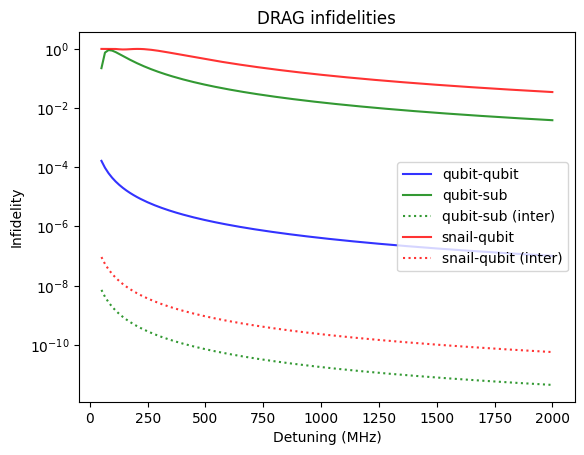

In [4]:
for label, fidelities in dragged_fidelity_results.items():
    color, linestyle = color_map[label]
    plt.plot(detuning_list, fidelities, color=color, alpha=0.8, linestyle=linestyle, label=label)
plt.title("DRAG infidelities")
plt.xlabel("Detuning (MHz)")
plt.ylabel("Infidelity")
plt.yscale("log")
plt.legend()
plt.show()

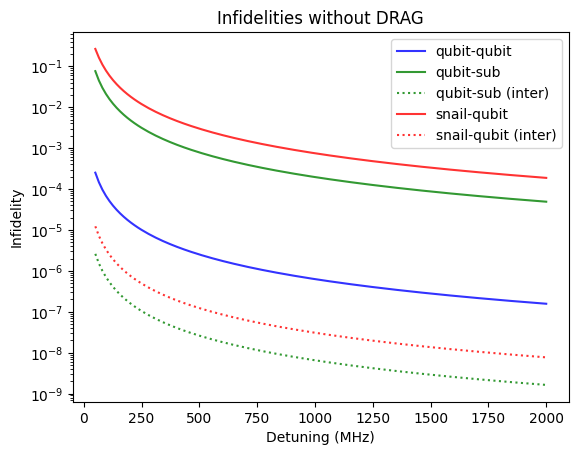

In [5]:
for label, fidelities in fidelity_results.items():
    color, linestyle = color_map[label]
    plt.plot(detuning_list, fidelities, color=color, alpha=0.8, linestyle=linestyle, label=label)
plt.title("Infidelities without DRAG")
plt.xlabel("Detuning (MHz)")
plt.ylabel("Infidelity")
plt.yscale("log")
plt.legend()
plt.show()

In [ ]:
# === Plotting with Clear Distinction Between Data and Fit === #
color_map = {
    "qubit-qubit": ("blue", "-"),
    "snail-qubit": ("orange", "-"),
    "snail-qubit (inter)": ("orange", ":"),
    "qubit-sub": ("greenyellow", "-"),
    "qubit-sub (inter)": ("greenyellow", ":"),
}

def plot_variant(ax, detuning_list, fidelity_results, infidelity_params, color_map,
                 *, data_ls="-", fit_ls="--", plot_fit=True, alpha=0.7):
    """Plot one variant's curves. Color encodes spectator, linestyle encodes variant.
 
    Returns (handles, labels) split into intra / inter for the spectator legend.
    Only the first variant you plot needs its handles kept — colors are shared,
    so the spectator legend is built once and the variant legend carries the
    regular-vs-DRAG distinction separately.
    """
    h_intra, l_intra, h_inter, l_inter = [], [], [], []
    for label, fidelities in fidelity_results.items():
        color, _ = color_map[label]
        (line,) = ax.plot(detuning_list, fidelities,
                          color=color, linestyle=data_ls, alpha=alpha)
        disp = label.replace(" (inter)", "").replace("snail-qubit", "SNAIL-qubit")
        if " (inter)" in label:
            h_inter.append(line); l_inter.append(disp)
        else:
            h_intra.append(line); l_intra.append(disp)
 
    if plot_fit:
        for label, params in infidelity_params.items():
            color, _ = color_map[label]
            ax.plot(detuning_list, decay_fit(detuning_list, *params),
                    color=color, linestyle=fit_ls, linewidth=1.0, alpha=0.5)
 
    return (h_intra, l_intra), (h_inter, l_inter)

def make_figure(detuning_list,
                fidelity_results, infidelity_params,
                drag_fidelity_results, drag_infidelity_params,
                plot_fit=True,
                style=("ieee", "use_mathtext", "science")):
    """Build the regular+DRAG figure entirely inside your style context."""
    with plt.style.context(list(style)):
        fig, ax = plt.subplots(figsize=(3.5, 3))
 
        # Regular: solid data, dashed fit. Keep handles for the spectator legend.
        (h_intra, l_intra), (h_inter, l_inter) = plot_variant(
            ax, detuning_list, fidelity_results, infidelity_params, color_map,
            data_ls="-", fit_ls="--", plot_fit=plot_fit)
 
        # DRAG: dash-dot data, dotted fit. Same colors -> no new spectator entries.
        plot_variant(
            ax, detuning_list, drag_fidelity_results, drag_infidelity_params,
            color_map, data_ls="-.", fit_ls=":", plot_fit=plot_fit)
 
        ax.set_xlabel("Detuning (MHz)")
        ax.set_ylabel("Infidelity")
        ax.set_yscale("log")
        ax.grid(True)
 
        legend_intra = ax.legend(h_intra, l_intra, title="Intra", loc="upper center",
                                 bbox_to_anchor=(0.15, -0.1), ncol=1, fontsize=10)
        legend_inter = ax.legend(h_inter, l_inter, title="Inter", loc="upper center",
                                 bbox_to_anchor=(0.5, -0.1), ncol=1, fontsize=10)
        variant_handles = [Line2D([0], [0], color="0.3", linestyle="-"),
                           Line2D([0], [0], color="0.3", linestyle="-.")]
        legend_variant = ax.legend(variant_handles, ["Regular", "DRAG"], title="Pulse",
                                   loc="upper center", bbox_to_anchor=(0.85, -0.1),
                                   ncol=1, fontsize=10)
        ax.add_artist(legend_intra)
        ax.add_artist(legend_inter)
        ax.add_artist(legend_variant)
 
        fig.subplots_adjust(bottom=0.3)
        legs = [legend_intra, legend_inter, legend_variant]
 
        plt.show()
        fig.savefig("fidelity_vs_terms_damped_fit.pdf",
                    bbox_inches="tight", bbox_extra_artists=legs)
    return fig, ax, legs


/tmp/ipykernel_11925/2096661648.py:70: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  legend_intra = ax.legend(
/tmp/ipykernel_11925/2096661648.py:80: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  legend_inter = ax.legend(


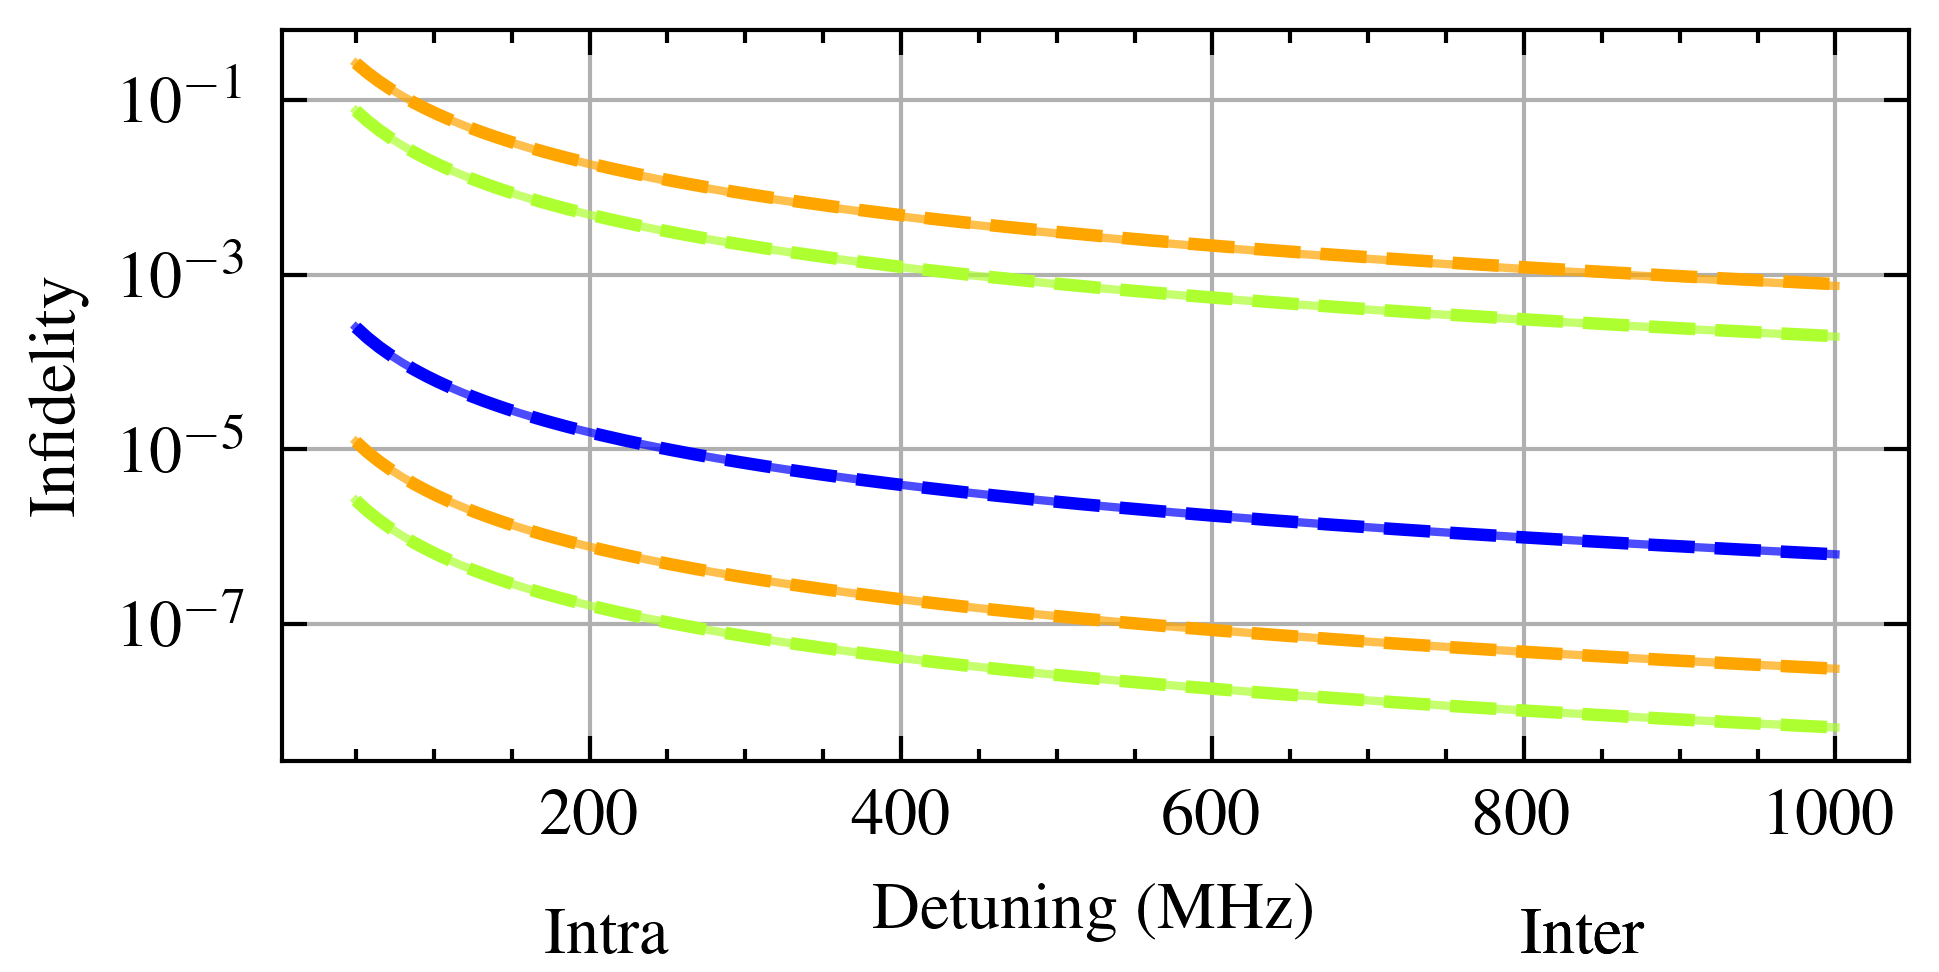

In [ ]:

with plt.style.context(["ieee", "use_mathtext", "science"]):
    fig, ax = plt.subplots(figsize=(3.5, 3))

    # Prepare separate lists for raw-data legend entries:
    handles_intra = []
    labels_intra = []
    handles_inter = []
    labels_inter = []

    # Plot raw data (scatter) and build the legend lists
    for label, fidelities in fidelity_results.items():
        color, linestyle = color_map[label]
        # Choose marker style based on whether the label is 'inter'
        if " (inter)" in label:
            marker = "*"  # Square marker for inter data
        else:
            marker = "o"  # Dot marker for intra data

        sc = ax.plot(
            detuning_list,
            fidelities,
            label=label,  # keep original key for plotting
            color=color,
            # marker=marker,
            alpha=0.7,
        )
        # Modify the label for legend display:
        # • Remove " (inter)" if present.
        # • Replace "snail-qubit" with "SNAIL-qubit" for display.
        if " (inter)" in label:
            clean_label = label.replace(" (inter)", "")
            if "snail-qubit" in clean_label:
                clean_label = clean_label.replace("snail-qubit", "SNAIL-qubit")
            handles_inter.append(sc)
            labels_inter.append(clean_label)
        else:
            new_label = label
            if "snail-qubit" in new_label:
                new_label = new_label.replace("snail-qubit", "SNAIL-qubit")
            handles_intra.append(sc)
            labels_intra.append(new_label)

    # Plot damped decay fits (line plots) without legend labels
    for label, params in infidelity_params.items():
        fit_curve = decay_fit(detuning_list, *params)
        color, linestyle = color_map[label]
        ax.plot(
            detuning_list,
            fit_curve,
            color=color,
            linestyle="--",
            linewidth=1.5,
        )

    ax.set_xlabel("Detuning (MHz)")
    ax.set_ylabel("Infidelity")
    ax.set_yscale("log")
    ax.grid(True)

    # Create the legend for Intra raw data
    legend_intra = ax.legend(
        handles_intra,
        labels_intra,
        title="Intra",
        loc="upper center",
        bbox_to_anchor=(0.2, -0.1),  # adjust horizontal position as needed
        ncol=1,
        fontsize=10,
    )
    # Create the legend for Inter raw data
    legend_inter = ax.legend(
        handles_inter,
        labels_inter,
        title="Inter",
        loc="upper center",
        bbox_to_anchor=(0.8, -0.1),  # adjust horizontal position as needed
        ncol=1,
        fontsize=10,
    )
    # Add both legends so that they appear together
    ax.add_artist(legend_intra)
    ax.add_artist(legend_inter)

    # Increase bottom margin so the legends are fully visible
    fig.subplots_adjust(bottom=0.3)

    plt.show()
    fig.savefig(
        "fidelity_vs_terms_damped_fit.pdf",
        bbox_inches="tight",
        bbox_extra_artists=[legend_intra, legend_inter],
    )